In [9]:
import numpy as np
from scipy.integrate import solve_ivp
from matplotlib import pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import minimize


In [ ]:
class MenstrualModel:
    def __init__(self, 
                 compartments=None, 
                 initial_hormones=None,
                 time_domain=(0, 1),
                 resolution=100,
                 parameters=None):
        """
        compartments: list of compartment names
        initial_hormones: dict with initial values for each compartment
        time_domain: tuple (t0, tf)
        resolution: number of time points
        parameters: nested dictionary of synthesis, clearance, and regulatory parameters
        """
        # Default compartments
        self.compartments = ['GnRH', 'LH', 'Estrogen', 'FSH', 'Progesterone', 'Tissue', 'LTissue'] if compartments is None else compartments
        self.compartment_to_index = {name: i for i, name in enumerate(self.compartments)}
        
        # Time domain
        self.time_domain = time_domain
        self.resolution = resolution
        self.t = np.linspace(time_domain[0], time_domain[1], resolution)
        
        # Parameters
        self.params = self._create_default_params() if parameters is None else self._create_default_params() | parameters
        
        # Initial hormone values
        if not isinstance(initial_hormones, dict):
            raise ValueError("Need a dictionary of initial conditions")
        if set(self.compartments) != set(initial_hormones.keys()):
            raise ValueError(f"Compartments and initial conditions keys must match!\n"
                             f"Compartments: {self.compartments}\n"
                             f"Initial conditions: {list(initial_hormones.keys())}")
        self.y0 = self._create_initial_condition(**initial_hormones)
    
    def _create_initial_condition(self, **initial_hormones):
        y0 = np.zeros(len(self.compartments))
        for comp in self.compartments:
            y0[self.compartment_to_index[comp]] = initial_hormones[comp]
        return y0
    
    def unpack(self, y):
        """Return a dict mapping compartment names to values."""
        return {comp: y[self.compartment_to_index[comp]] for comp in self.compartments}
    
    # Hill functions
    @staticmethod
    def hill_activate(K, n, P):
        P = np.maximum(P, 1e-12)
        K = np.maximum(K, 1e-12)
        n = np.maximum(n, 1e-12)

        Pn = np.exp(n * np.log(P))
        Kn = np.exp(n * np.log(K))

        return Pn / (Kn + Pn)


    @staticmethod
    def hill_repress(K, n, P):
        P = np.maximum(P, 1e-12)
        K = np.maximum(K, 1e-12)
        n = np.maximum(n, 1e-12)

        Pn = np.exp(n * np.log(P))
        Kn = np.exp(n * np.log(K))

        return Kn / (Kn + Pn)
    
    @staticmethod
    def hill_biphasic(K1, K2, n1, n2, P):
        return MenstrualModel.hill_activate(K1, n1, P) * MenstrualModel.hill_repress(K2, n2, P)
    
    @staticmethod
    def clamp(inputs, min_val, max_val):
        return [np.clip(i, min_val, max_val) for i in inputs]
    
    def ode(self, t, y):
        h = self.unpack(y)
        #clamping hormones to avoid numerical instability
        GnRH, LH, Estrogen, FSH, Tissue = self.clamp((h['GnRH'], h['LH'], h['Estrogen'], h['FSH'], h['Tissue']), 1e-8, np.inf)

        # ---------------- GnRH ----------------
        synth_GnRH = self.params['synthesis']['GnRH']
        clearance_GnRH = self.params['clearance']['GnRH']
        n_EGnRH1, n_EGnRH2 = self.params['regulatory'][('Estrogen', 'GnRH')]['n']
        K_EGnRH1, K_EGnRH2 = self.params['regulatory'][('Estrogen', 'GnRH')]['K']
        
        dGnRH = (synth_GnRH * (self.hill_biphasic(K_EGnRH1, K_EGnRH2, n_EGnRH1, n_EGnRH2, Estrogen))
                 - clearance_GnRH * GnRH)
        
        # ---------------- LH ----------------
        synth_LH = self.params['synthesis']['LH']
        clearance_LH = self.params['clearance']['LH']
        n_GLH = self.params['regulatory'][('GnRH', 'LH')]['n']
        K_GLH = self.params['regulatory'][('GnRH', 'LH')]['K']
        
        dLH = (synth_LH * self.hill_activate(K_GLH, n_GLH, GnRH)
               - clearance_LH * LH)
        
        # ---------------- FSH ----------------
        synth_FSH = self.params['synthesis']['FSH']
        clearance_FSH = self.params['clearance']['FSH']
        K_GFSH = self.params['regulatory'][('GnRH', 'FSH')]['K']
        n_GFSH = self.params['regulatory'][('GnRH', 'FSH')]['n']

        dFSH = (synth_FSH * self.hill_activate(K_GFSH, n_GFSH, GnRH) - clearance_FSH * FSH)
        
        # ---------------- Tissue ----------------
        growth_Tissue = self.params['synthesis']['Tissue']
        clearance_Tissue = self.params['clearance']['Tissue']
        K_LHTissue, n_LHTissue = self.params['regulatory'][('LH', 'Tissue')]['K'], self.params['regulatory'][('LH', 'Tissue')]['n']

        dTissue = growth_Tissue * FSH - clearance_Tissue * self.hill_activate(K_LHTissue, n_LHTissue, LH) * Tissue

        # ---------------- Estrogen ----------------
        synth_estrogen = self.params['synthesis']['Estrogen']
        Estrogen = synth_estrogen * Tissue

        return np.array([dGnRH, dLH, dFSH, dTissue, Estrogen])
    
    def simulate(self, method='RK45'):
        """Simulate the ODE system over the time domain."""
        sol = solve_ivp(fun=self.ode, t_span=self.time_domain, y0=self.y0,
                        t_eval=self.t, method=method)
        return sol
    
    def _create_default_params(self):
        #TODO UPDATE THIS WITH THE NEW COMPARTMENTS

        """Return a default parameter dictionary."""
        return {
            'synthesis': {
                'GnRH': 1.0,  # (GnRH autoregulation, Estrogen effect)
                'LH': 1.0,    # (GnRH effect, Estrogen effect)
                'Estrogen': 1.0       # (LH effect)
            },
            'clearance': {
                'GnRH': 0.1,
                'LH': 0.1,
                'Estrogen': 0.1
            },
            'regulatory': {
                ('Estrogen', 'GnRH'): {'n': (2, 5), 'K': (0.5, 2.0)},
                ('GnRH', 'LH'): {'n': 3, 'K': 1.0},
                ('LH', 'Estrogen'): {'n': (2, 4), 'K': (0.5, 2.0)}
            }
        }
    
    def plot(self, sol, compartments=None, title="Menstrual Cycle Model"):
        if compartments is None:
            compartments=self.compartments

        plt.figure(figsize=(7, 4))
        for name in compartments:
            if name not in self.compartments:
                raise ValueError(f"Trying to plot nonexistent compartment: {name}")
            i = self.compartment_to_index[name]
            plt.plot(sol.t, sol.y[i], label=name)
        
        plt.vlines(x=14, ymin=0, ymax=8, linestyles='--', colors='black')
        plt.xlabel("Days")
        plt.ylabel("Horomone Concentrations")
        plt.title(title)
        plt.legend(loc="upper right")
        plt.show()

In [11]:
initial_conditions = {
    'GnRH': 1.0,
    'LH': 0.25,
    'Estrogen': 1.0
}

In [12]:
parameters = {
    'synthesis': {
        'GnRH': 1.0,  # (GnRH autoregulation, Estrogen effect)
        'LH': 1.0,    # (GnRH effect, Estrogen effect)
        'Estrogen': 2.0       # (LH effect)
    },
    'clearance': {
        'GnRH': 0.2,
        'LH': 0.1,
        'Estrogen': 0.2
    },
    'regulatory': {
        ('Estrogen', 'GnRH'): {'n': (10, 3), 'K': (0.09, 1.0)},
        ('GnRH', 'LH'): {'n': 12, 'K': 4.0},
        ('LH', 'Estrogen'): {'n': (10, 10), 'K': (1.0, 20.0)}
    }
}

model = MenstrualModel(initial_hormones=initial_conditions, time_domain=(0, 2 * 28), resolution=1000, parameters=parameters)
sol = model.simulate()
model.plot(sol)

ValueError: Compartments and initial conditions keys must match!
Compartments: ['GnRH', 'LH', 'Estrogen', 'FSH', 'Progesterone', 'FTissue', 'LTissue']
Initial conditions: ['GnRH', 'LH', 'Estrogen']

### Fitting to data from PhD disertation

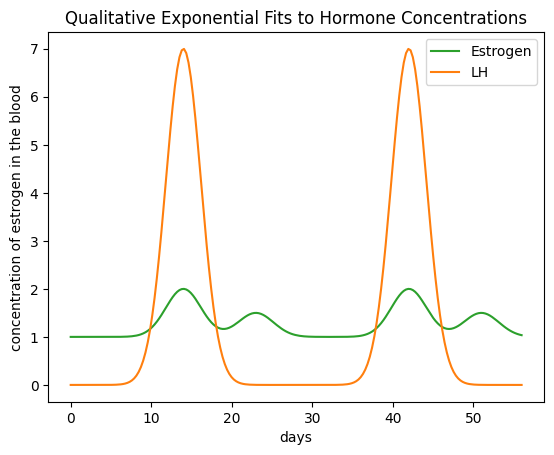

In [ ]:
def plot_input_data():
    estradiol_function = lambda x: 1 + 1 * np.exp(-(x-14)**2/(9.5)) + 0.5 * np.exp(-(x-23)**2/(9.5)) + 1 * np.exp(-(x-42)**2/(9.5))+ 0.5 * np.exp(-(x-51)**2/(9.5))
    LH_function = lambda x: 0 + 7 * np.exp(-(x-14)**2/(9.5)) + 7 * np.exp(-(x-42)**2/(9.5))
    x = np.linspace(0, 56, 200)
    plt.plot(x, estradiol_function(x), color='tab:green', label='Estrogen')
    plt.plot(x, LH_function(x), color='tab:orange', label='LH')
    plt.gca().set(xlabel='days', ylabel='concentration of estrogen in the blood', ylim=(0, 8), title='Qualitative Exponential Fits to Hormone Concentrations')
    plt.autoscale(enable=True, axis='y', tight=False)
    plt.legend()

plot_input_data()

In [ ]:
def unpack_params(p):
    return (
        # synthesis
        p['synthesis']['GnRH'],
        p['synthesis']['LH'],
        p['synthesis']['Estrogen'],

        # clearance
        p['clearance']['GnRH'],
        p['clearance']['LH'],
        p['clearance']['Estrogen'],

        # regulatory: Estrogen -> GnRH
        *p['regulatory'][('Estrogen', 'GnRH')]['n'],
        *p['regulatory'][('Estrogen', 'GnRH')]['K'],

        # regulatory: GnRH -> LH
        p['regulatory'][('GnRH', 'LH')]['n'],
        p['regulatory'][('GnRH', 'LH')]['K'],

        # regulatory: LH -> Estrogen
        *p['regulatory'][('LH', 'Estrogen')]['n'],
        *p['regulatory'][('LH', 'Estrogen')]['K'],
    )

def pack_params(theta):
    it = iter(theta)

    return {
        'synthesis': {
            'GnRH': next(it),
            'LH': next(it),
            'Estrogen': next(it)
        },
        'clearance': {
            'GnRH': next(it),
            'LH': next(it),
            'Estrogen': next(it)
        },
        'regulatory': {
            ('Estrogen','GnRH'): {
                'n': (next(it), next(it)),
                'K': (next(it), next(it))
            },
            ('GnRH','LH'): {
                'n': next(it),
                'K': next(it)
            },
            ('LH','Estrogen'): {
                'n': (next(it), next(it)),
                'K': (next(it), next(it))
            }
        }
    }

In [ ]:
estradiol_function = lambda x: 1 + 1 * np.exp(-(x-14)**2/(9.5)) + 1 * np.exp(-(x-42)**2/(9.5))
LH_function = lambda x: 0 + 7 * np.exp(-(x-14)**2/(9.5)) + 7 * np.exp(-(x-42)**2/(9.5))

def calculate_error(param):
    
    param_dict = pack_params(param)
    model = MenstrualModel(initial_hormones=initial_conditions, time_domain=(0, 62), resolution=400, parameters=param_dict)
    sol = model.simulate()

    #using soft rejections to avoid finding areas where there is no gradient
    if not sol.success or np.any(np.isnan(sol.y)):
        return 1e6 + np.sum(param**2)

    if np.any(sol.y > 1e6):
        return 1e6 + np.max(sol.y)

    diff_e = sol.y[model.compartment_to_index["Estrogen"]] - estradiol_function(sol.t)
    diff_l = sol.y[model.compartment_to_index['LH']] - LH_function(sol.t)
    return  (np.linalg.norm((diff_e))**2 + 1.1 * np.linalg.norm(diff_l)**2)
    

In [ ]:
bounds = [
    # synthesis
    (1e-6, 20),   # GnRH synthesis
    (1e-6, 20),   # LH synthesis
    (1e-6, 20),   # Estrogen synthesis

    # clearance
    (1e-6, 5),    # GnRH clearance
    (1e-6, 5),    # LH clearance
    (1e-6, 5),    # Estrogen clearance

    # Estrogen -> GnRH (n1, n2)
    (1, 10),
    (1, 10),

    # Estrogen -> GnRH (K1, K2)
    (1e-3, 50),
    (1e-3, 50),

    # GnRH -> LH (n)
    (1, 10),

    # GnRH -> LH (K)
    (1e-3, 50),

    # LH -> Estrogen (n1, n2)
    (1, 10),
    (1, 10),

    # LH -> Estrogen (K1, K2)
    (1e-3, 50),
    (1e-3, 50),
]

### Optimization Step

In [ ]:
potential_parameters3 = {'synthesis': {'GnRH': 19.080747653063103, 'LH': 8.963555194404625, 'Estrogen': 0.6056126877969}, 'clearance': {'GnRH': 0.17875227099155017, 'LH': 0.4430667974310022, 'Estrogen': 0.063340734727207635}, 'regulatory': {('Estrogen', 'GnRH'): {'n': (6.015909299621474, 4.047512877455463), 'K': (0.08960562158967206, 0.35737934691168777)}, ('GnRH', 'LH'): {'n': 6.000006411562403, 'K': 7.118882087275408}, ('LH', 'Estrogen'): {'n': (4.960342694057574, 6.000006594059802), 'K': (7.663371484226182, 20.000071881535508)}}}


In [ ]:
params = unpack_params(potential_parameters3)
result = minimize(calculate_error, params, options={"maxiter": 200, 'maxls': 50, "disp": True}, tol=1e-11, method='L-BFGS-B', bounds=bounds)
best_parameters = pack_params(result.x)

In [ ]:
print(best_parameters)

{'synthesis': {'GnRH': 18.506785606338244, 'LH': 8.693633372056874, 'Estrogen': 1.1935064388097294}, 'clearance': {'GnRH': 0.22582434947213273, 'LH': 0.44143085886721795, 'Estrogen': 0.049388934914272625}, 'regulatory': {('Estrogen', 'GnRH'): {'n': (6.016336143568173, 4.221850151013043), 'K': (0.08694672050650507, 0.3947546030817187)}, ('GnRH', 'LH'): {'n': 6.118871949197061, 'K': 8.408535159988482}, ('LH', 'Estrogen'): {'n': (5.110351103115173, 6.12033828043598), 'K': (7.4300767020961285, 20.862567193230298)}}}


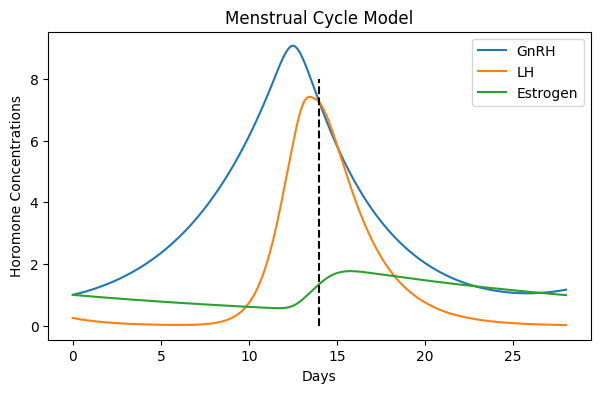

In [ ]:
model = MenstrualModel(initial_hormones=initial_conditions, time_domain=(0, 28), resolution=1000, parameters=best_parameters)
sol = model.simulate()
model.plot(sol)

### Good Parameter Set 1

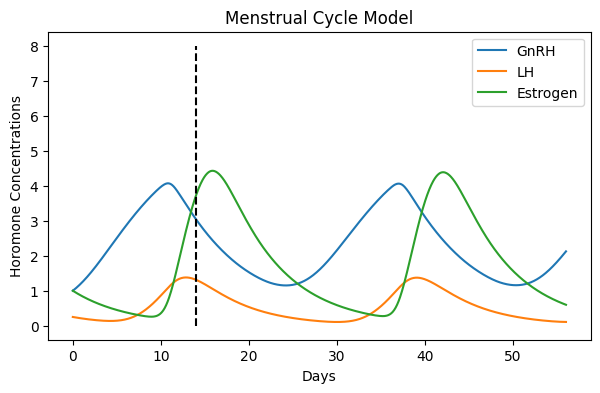

In [ ]:
potential_parameters = {
    'synthesis': {
        'GnRH': 0.72,
        'LH': 0.99,
        'Estrogen': 2.05
    },
    'clearance': {
        'GnRH': 0.12,
        'LH': 0.18,
        'Estrogen': 0.16
    },
    'regulatory': {
        ('Estrogen', 'GnRH'): {
            'n': (6.00, 2.99),
            'K': (0.08, 0.92)
        },
        ('GnRH', 'LH'): {
            'n': 6.00,
            'K': 4.16
        },
        ('LH', 'Estrogen'): {
            'n': (5.64, 6.00),
            'K': (1.18, 20.00)
        }
    }
}

model = MenstrualModel(initial_hormones=initial_conditions, time_domain=(0, 2*28), resolution=1000, parameters=potential_parameters)
sol = model.simulate()
model.plot(sol)


### Good Parameter Set 2

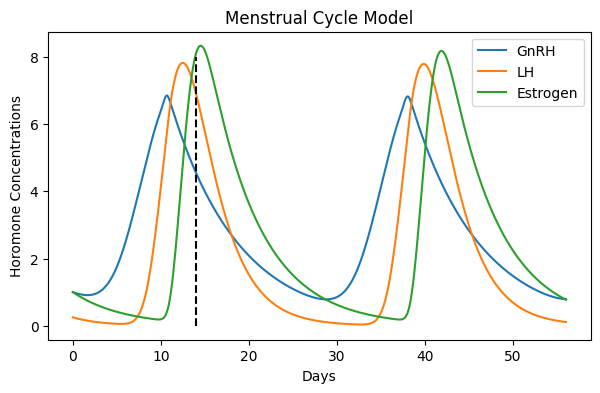

In [ ]:
potential_parameters2 = {'synthesis': {'GnRH': 1.881570358425819, 'LH': 5.933149093881693, 'Estrogen': 8.187683301977076}, 'clearance': {'GnRH': 0.13000617656597083, 'LH': 0.3067048084905143, 'Estrogen': 0.1767308951793158}, 'regulatory': {('Estrogen', 'GnRH'): {'n': (9.998655901831478, 4.264006109570467), 'K': (0.15238630618477622, 0.39543036930458536)}, ('GnRH', 'LH'): {'n': 5.6198200973955315, 'K': 5.9303541491918095}, ('LH', 'Estrogen'): {'n': (6.897795014253463, 9.999995916078644), 'K': (7.891117441817578, 20.00000004328206)}}}
model = MenstrualModel(initial_hormones=initial_conditions, time_domain=(0, 2*28), resolution=1000, parameters=potential_parameters2)
sol = model.simulate()
model.plot(sol)

### Good Parameter Set 3

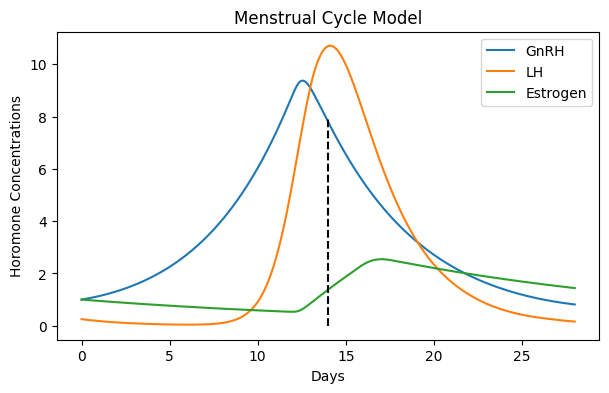

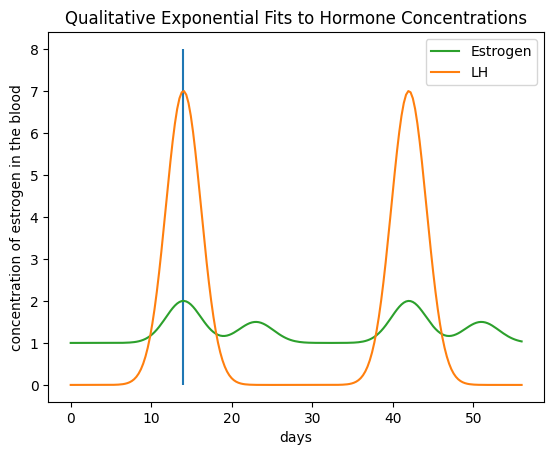

In [ ]:
potential_parameters3 = {'synthesis': {'GnRH': 19.080747653063103, 'LH': 8.963555194404625, 'Estrogen': 0.6056126877969}, 'clearance': {'GnRH': 0.17875227099155017, 'LH': 0.3430667974310022, 'Estrogen': 0.053340734727207635}, 'regulatory': {('Estrogen', 'GnRH'): {'n': (6.015909299621474, 4.047512877455463), 'K': (0.08960562158967206, 0.35737934691168777)}, ('GnRH', 'LH'): {'n': 6.000006411562403, 'K': 8.118882087275408}, ('LH', 'Estrogen'): {'n': (10.960342694057574, 6.000006594059802), 'K': (7, 20.000071881535508)}}}
model = MenstrualModel(initial_hormones=initial_conditions, time_domain=(0, 1*28), resolution=1000, parameters=potential_parameters3)
sol = model.simulate()
model.plot(sol)
plt.vlines(x=14, ymin=0, ymax=8)
plot_input_data()

### Size of the LH effect of estrogen

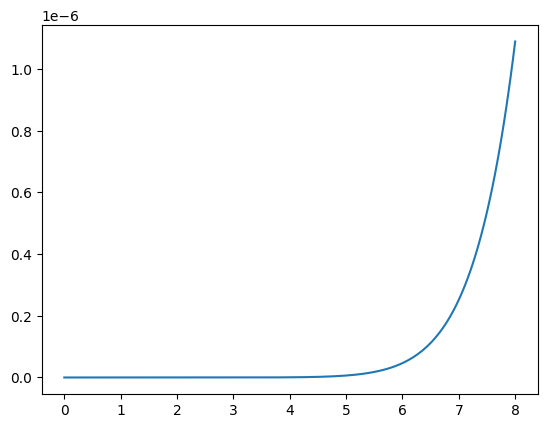

In [ ]:
K1, K2 = potential_parameters3['regulatory'][('LH', 'Estrogen')]['K']
n1, n2 = potential_parameters3['regulatory'][('LH', 'Estrogen')]['n']
plt.plot(np.linspace(0, 8, 200), MenstrualModel.hill_biphasic(K1, K2, n1, n2, np.linspace(0, 2, 200)))

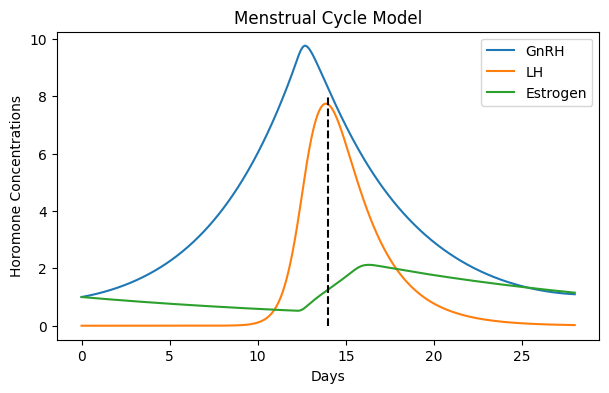

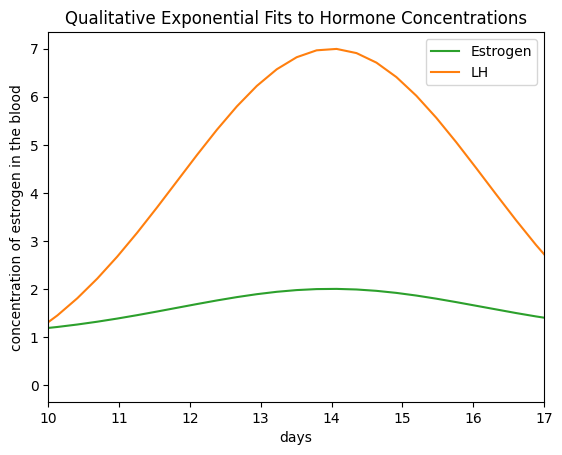

In [ ]:
potential_parameters = {'synthesis': {'GnRH': 18.506785606338244, 'LH': 8.693633372056874, 'Estrogen': 1.1935064388097294}, 'clearance': {'GnRH': 0.22582434947213273, 'LH': 0.44143085886721795, 'Estrogen': 0.1388934914272625}, 'regulatory': {('Estrogen', 'GnRH'): {'n': (10.016336143568173, 6.4221850151013043), 'K': (100, 2.00947546030817187)}, ('GnRH', 'LH'): {'n': 6.118871949197061, 'K': 8.408535159988482}, ('LH', 'Estrogen'): {'n': (6.110351103115173, 4.12033828043598), 'K': (0.4300767020961285, 20.862567193230298)}}}
initial_conditions = {
    'GnRH': 1.0,
    'LH': 0.0,
    'Estrogen': 1.0
}

model = MenstrualModel(initial_hormones=initial_conditions, time_domain=(0, 1*28), resolution=1000, parameters=potential_parameters3)
sol = model.simulate()
model.plot(sol)
plt.xlim(left=10, right=17)
plot_input_data()